# Notebook 12 — Robustness, Ablation & Final Evaluation

## Purpose

This is the final analytical notebook in the Patient Similarity Network + ABM Readmission project.

It evaluates whether the intervention findings from Notebook 11 are sensitive to:

1. similarity metric;
2. network size **k**;
3. intervention budget;
4. intervention effectiveness;
5. stochasticity / replication;
6. centrality choice;
7. feature-only, network-only, risk-only, and risk+network targeting.

The notebook uses the frozen validation population and saved Notebook 11 outputs. The final test set is **not loaded or used**.

## Important interpretation rule

This notebook evaluates robustness of a **simulation experiment**. It does not establish a clinical treatment effect, causality, or that network centrality causes readmission.

The network remains a **clinical/patient similarity network**, not a social network.

## 01. Critical rules and final-analysis contract

Before running, verify these rules:

- Validation population only.
- No test patients are loaded.
- No observed validation readmission outcome is used to construct a network or choose intervention targets.
- The same intervention budget is used when policies are compared within a scenario.
- Random seeds are recorded.
- The primary Notebook 11 configuration is retained as the reference scenario.
- Sensitivity analyses vary one assumption at a time where practical.
- Results are reported with simulation uncertainty.
- No final claim is made from a single stochastic run.

**Primary reference scenario from Notebook 11**

- cosine similarity;
- mutual-kNN;
- k = 10;
- intervention budget = 10%;
- Notebook 11 intervention-effect parameter;
- risk + network targeting.

**Ablation families**

- risk-only;
- network-only;
- risk + network;
- feature-only proxy;
- random baseline.

In [1]:
# 02. Imports and reproducibility

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import ttest_1samp

from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

SEED = 42
N_REPLICATIONS = 100

np.random.seed(SEED)

print("Python analysis environment initialized.")
print("Seed:", SEED)
print("Replications:", N_REPLICATIONS)

Python analysis environment initialized.
Seed: 42
Replications: 100


In [2]:
# 03. Locate project root and results directory

def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for root in candidates:
        if (
            (root / "results").exists()
            and (root / "notebooks").exists()
        ):
            return root

    raise FileNotFoundError(
        "Could not locate project root containing both 'results' and 'notebooks'."
    )

ROOT = find_project_root()
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

FIGURES.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Results:", RESULTS)
print("Figures:", FIGURES)

Project root: c:\Users\Gayatri\OneDrive\Desktop\sna
Results: c:\Users\Gayatri\OneDrive\Desktop\sna\results
Figures: c:\Users\Gayatri\OneDrive\Desktop\sna\figures


## 04. Required frozen inputs

Notebook 12 reads previously saved results rather than silently regenerating earlier stages.

Required:

- `11_intervention_replication_results.csv`
- `11_intervention_policy_summary.csv`
- `11_paired_policy_comparisons.csv`
- `11_target_selection_audit.csv`
- `11_validation_network_nodes.csv`
- `11_intervention_config.json`
- `05_X_validation.npz`
- `05_validation_feature_patient_ids.csv`

The validation feature matrix is used only for network-sensitivity analyses.

In [3]:
# 05. Verify and load frozen inputs

required_files = [
    "11_intervention_replication_results.csv",
    "11_intervention_policy_summary.csv",
    "11_paired_policy_comparisons.csv",
    "11_target_selection_audit.csv",
    "11_validation_network_nodes.csv",
    "11_intervention_config.json",
    "05_X_validation.npz",
    "05_validation_feature_patient_ids.csv",
]

missing = [name for name in required_files if not (RESULTS / name).exists()]

if missing:
    raise FileNotFoundError(
        "STOP: required frozen inputs are missing:\n" + "\n".join(missing)
    )

replication_results = pd.read_csv(
    RESULTS / "11_intervention_replication_results.csv"
)
policy_summary = pd.read_csv(
    RESULTS / "11_intervention_policy_summary.csv"
)
paired_results = pd.read_csv(
    RESULTS / "11_paired_policy_comparisons.csv"
)
target_audit = pd.read_csv(
    RESULTS / "11_target_selection_audit.csv"
)
network_nodes = pd.read_csv(
    RESULTS / "11_validation_network_nodes.csv"
)

with open(RESULTS / "11_intervention_config.json", "r", encoding="utf-8") as f:
    intervention_config = json.load(f)

X_validation = sparse.load_npz(RESULTS / "05_X_validation.npz")
validation_feature_ids = pd.read_csv(
    RESULTS / "05_validation_feature_patient_ids.csv"
)

print("Replication results:", replication_results.shape)
print("Policy summary:", policy_summary.shape)
print("Paired results:", paired_results.shape)
print("Target audit:", target_audit.shape)
print("Network nodes:", network_nodes.shape)
print("Validation feature matrix:", X_validation.shape)
print("Validation feature IDs:", validation_feature_ids.shape)

print("\nPolicies:", replication_results["policy"].unique().tolist())

Replication results: (400, 13)
Policy summary: (4, 12)
Paired results: (3, 6)
Target audit: (2, 5)
Network nodes: (10728, 11)
Validation feature matrix: (10728, 57)
Validation feature IDs: (10728, 1)

Policies: ['no_intervention', 'random', 'risk_based', 'network_informed']


In [4]:
# 06. Freeze configuration and validate validation-only population

assert "test" not in " ".join(
    replication_results.columns
).lower()

assert len(network_nodes) == len(validation_feature_ids)

required_node_columns = {
    "patient_id",
    "baseline_risk",
    "transition_probability",
    "validation_weighted_degree",
    "community",
    "network_informed_score",
}

missing_node_columns = required_node_columns - set(network_nodes.columns)

if missing_node_columns:
    raise AssertionError(
        f"STOP: Notebook 11 node output is missing {sorted(missing_node_columns)}"
    )

network_nodes["patient_id"] = (
    network_nodes["patient_id"].astype(str).str.strip()
)
validation_feature_ids["patient_nbr"] = (
    validation_feature_ids["patient_nbr"].astype(str).str.strip()
)

assert network_nodes["patient_id"].is_unique
assert validation_feature_ids["patient_nbr"].is_unique
assert len(network_nodes) == X_validation.shape[0]

# No final test prediction/outcome is loaded.
TEST_FILES = list(RESULTS.glob("*test*"))
print("Test-named result files present on disk:", len(TEST_FILES))
print("PASS | Notebook 12 uses validation population only")
print("PASS | validation feature matrix aligned")

Test-named result files present on disk: 7
PASS | Notebook 12 uses validation population only
PASS | validation feature matrix aligned


## 07. Reference scenario from Notebook 11

The reference scenario is retained exactly as the baseline for robustness comparisons.

The Notebook 11 output already contains the four-policy stochastic experiment. Notebook 12 does not overwrite it.

We first inspect the saved reference results.

In [5]:
# 08. Inspect Notebook 11 reference results

print("Notebook 11 configuration:")
print(json.dumps(intervention_config, indent=2))

print("\nPolicy summary:")
display(policy_summary)

print("\nTarget selection audit:")
display(target_audit)

Notebook 11 configuration:
{
  "notebook": "11_intervention_experiments",
  "seed": 42,
  "replications": 100,
  "validation_population_only": true,
  "test_used": false,
  "validation_patients": 10728,
  "intervention_budget_fraction": 0.1,
  "intervention_count": 1073,
  "intervention_effect": 0.2,
  "validation_network": {
    "metric": "cosine",
    "rule": "mutual_knn",
    "k": 10,
    "nodes": 10728,
    "edges": 30245
  },
  "network_informed_score": {
    "risk_weight": 0.7,
    "network_weight": 0.2,
    "community_risk_weight": 0.1
  },
  "policies": [
    "no_intervention",
    "random",
    "risk_based",
    "network_informed"
  ],
  "common_random_numbers": true,
  "observed_outcome_used_for_targeting": false
}

Policy summary:


,policy,replications,patients_per_replication,intervention_count,mean_readmission_rate,sd_readmission_rate,ci95_low,ci95_high,mean_prevented_vs_no_intervention,mean_absolute_reduction,mean_relative_reduction,mean_intervention_efficiency
0,no_intervention,100.0,10728.0,0.0,0.123241,0.002561,0.122739,0.123743,0.00,0.000000,0.000000,NaN
1,random,100.0,10728.0,1073.0,0.120807,0.002580,0.120302,0.121313,26.11,0.002434,0.019753,0.024334
2,risk_based,100.0,10728.0,1073.0,0.110539,0.002549,0.110039,0.111038,136.27,0.012702,0.103080,0.126999
3,network_informed,100.0,10728.0,1073.0,0.112145,0.002574,0.111640,0.112649,119.04,0.011096,0.090053,0.110941



Target selection audit:


,policy,intervention_count,mean_baseline_risk,mean_network_importance,mean_network_informed_score
0,risk_based,1073,0.632192,4.475131,0.841855
1,network_informed,1073,0.550149,6.146062,0.862160


In [6]:
# 09. Reference-scenario sanity checks

expected_policies = {
    "no_intervention",
    "random",
    "risk_based",
    "network_informed",
}

assert expected_policies.issubset(
    set(replication_results["policy"].unique())
)

n_reps = replication_results["replication"].nunique()

assert n_reps >= 30, (
    f"STOP: only {n_reps} replications found; "
    "at least 30 are required for a meaningful stochastic robustness analysis."
)

assert replication_results["n_patients"].nunique() == 1
assert replication_results["intervention_count"].max() > 0

print("Reference replications:", n_reps)
print("Reference population:", replication_results["n_patients"].iloc[0])
print("PASS | four reference policies available")
print("PASS | adequate stochastic replications")

Reference replications: 100
Reference population: 10728
PASS | four reference policies available
PASS | adequate stochastic replications


## 10. Common simulation engine for sensitivity analysis

For robustness scenarios, the transition rule is deliberately kept simple and consistent with the ABM design:

\[
p_i^{scenario} =
clip(p_i^{baseline}(1 - e \cdot I_i), 0, 1)
\]

where:

- \(p_i^{baseline}\) is the frozen Notebook 09/11 transition probability;
- \(e\) is the scenario intervention effectiveness;
- \(I_i=1\) if patient \(i\) is targeted.

This is a **simulation sensitivity model**, not a clinical causal-effect model.

Common random numbers are used within each scenario so policy comparisons share the same stochastic outcome draws.

In [7]:
# 11. Prepare baseline probabilities and deterministic policy helpers

population = network_nodes.copy()

population["baseline_risk"] = pd.to_numeric(
    population["baseline_risk"], errors="coerce"
)
population["transition_probability"] = pd.to_numeric(
    population["transition_probability"], errors="coerce"
)
population["validation_weighted_degree"] = pd.to_numeric(
    population["validation_weighted_degree"], errors="coerce"
)
population["network_informed_score"] = pd.to_numeric(
    population["network_informed_score"], errors="coerce"
)

assert population["baseline_risk"].notna().all()
assert population["transition_probability"].notna().all()
assert population["transition_probability"].between(0, 1).all()

population["risk_percentile"] = population["baseline_risk"].rank(
    pct=True, method="average"
)
population["network_percentile"] = population[
    "validation_weighted_degree"
].rank(
    pct=True, method="average"
)

# A feature-only proxy is defined from the clinical-risk representation
# without using network variables. Since Notebook 05 has already compressed
# the leakage-safe clinical representation, the frozen baseline risk is used
# as the feature-only decision signal.
population["feature_only_score"] = population["baseline_risk"]

print("Patients:", len(population))
print("PASS | baseline probabilities valid")
print("PASS | feature-only score available without network variables")

Patients: 10728
PASS | baseline probabilities valid
PASS | feature-only score available without network variables


In [8]:
# 12. Create deterministic target sets

def select_targets(pop, policy, budget_count, rng):
    ids = pop["patient_id"].to_numpy()

    if policy == "random":
        return set(
            rng.choice(
                ids,
                size=budget_count,
                replace=False
            ).tolist()
        )

    if policy == "risk_only":
        order = pop.sort_values(
            ["baseline_risk", "patient_id"],
            ascending=[False, True]
        )
        return set(order.head(budget_count)["patient_id"])

    if policy == "network_only":
        order = pop.sort_values(
            ["validation_weighted_degree", "patient_id"],
            ascending=[False, True]
        )
        return set(order.head(budget_count)["patient_id"])

    if policy == "risk_network":
        score = (
            0.70 * pop["baseline_risk"].rank(pct=True)
            + 0.20 * pop["validation_weighted_degree"].rank(pct=True)
            + 0.10 * pop["community"].map(
                pop.groupby("community")["baseline_risk"].mean()
            ).rank(pct=True)
        )

        order = pop.assign(_score=score).sort_values(
            ["_score", "patient_id"],
            ascending=[False, True]
        )
        return set(order.head(budget_count)["patient_id"])

    if policy == "feature_only":
        order = pop.sort_values(
            ["feature_only_score", "patient_id"],
            ascending=[False, True]
        )
        return set(order.head(budget_count)["patient_id"])

    if policy == "no_intervention":
        return set()

    raise ValueError(f"Unknown policy: {policy}")


POLICY_NAMES = [
    "no_intervention",
    "random",
    "feature_only",
    "risk_only",
    "network_only",
    "risk_network",
]

print("Ablation policies:", POLICY_NAMES)

Ablation policies: ['no_intervention', 'random', 'feature_only', 'risk_only', 'network_only', 'risk_network']


## 13. Network sensitivity

The validation feature matrix from Notebook 05 is used to rebuild **validation-only** mutual-kNN networks.

Sensitivity values:

- k = 5
- k = 10
- k = 20
- k = 30

Similarity metrics:

- cosine
- Euclidean

No observed readmission target is used in network construction.

In [9]:
# 14. Build a validation-only mutual-kNN network

def build_mutual_knn_graph(X, ids, metric="cosine", k=10):
    n = X.shape[0]
    k_eff = min(k, n - 1)

    nn = NearestNeighbors(
        n_neighbors=k_eff + 1,
        metric=metric,
        algorithm="brute",
        n_jobs=-1
    )

    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    edge_map = {}

    for i in range(n):
        for pos in range(1, k_eff + 1):
            j = int(indices[i, pos])

            if i == j:
                continue

            if metric == "cosine":
                similarity = 1.0 - float(distances[i, pos])
            else:
                # Convert Euclidean distance to a bounded similarity.
                similarity = 1.0 / (1.0 + float(distances[i, pos]))

            similarity = float(np.clip(similarity, 0.0, 1.0))

            a, b = sorted((i, j))
            edge_map[(a, b)] = similarity

    # Mutual-kNN: retain an edge only when both directions contain each other.
    neighbor_sets = [
        set(row[1:k_eff + 1].tolist())
        for row in indices
    ]

    mutual_edges = []

    for (i, j), weight in edge_map.items():
        if j in neighbor_sets[i] and i in neighbor_sets[j]:
            mutual_edges.append((i, j, weight))

    return mutual_edges


def weighted_degree_from_edges(n, edges):
    degree = np.zeros(n, dtype=float)

    for i, j, weight in edges:
        degree[i] += weight
        degree[j] += weight

    return degree


print("Network builder ready.")

Network builder ready.


In [10]:
# 15. Run k/metric network sensitivity

ids = validation_feature_ids["patient_nbr"].astype(str).to_numpy()

network_sensitivity_records = []

for metric in ["cosine", "euclidean"]:
    for k in [5, 10, 20, 30]:

        edges = build_mutual_knn_graph(
            X_validation,
            ids,
            metric=metric,
            k=k
        )

        weighted_degree = weighted_degree_from_edges(
            len(ids),
            edges
        )

        network_sensitivity_records.append({
            "metric": metric,
            "k": k,
            "nodes": len(ids),
            "edges": len(edges),
            "density": (
                len(edges) /
                (len(ids) * (len(ids) - 1) / 2)
            ),
            "mean_weighted_degree": float(weighted_degree.mean()),
            "median_weighted_degree": float(np.median(weighted_degree)),
            "isolated_nodes": int((weighted_degree == 0).sum()),
        })

network_sensitivity = pd.DataFrame(network_sensitivity_records)

display(network_sensitivity)

assert len(network_sensitivity) == 8
assert (network_sensitivity["edges"] > 0).all()

print("PASS | similarity metric sensitivity completed")
print("PASS | k sensitivity completed")
print("PASS | validation-only networks used")

,metric,k,nodes,edges,density,mean_weighted_degree,median_weighted_degree,isolated_nodes
0,cosine,5,10728,14392,0.000250,2.480298,2.653894,953
1,cosine,10,10728,30245,0.000526,5.129076,5.237948,248
2,cosine,20,10728,62621,0.001088,10.416738,10.370403,34
3,cosine,30,10728,95851,0.001666,15.742751,15.727120,7
4,euclidean,5,10728,13850,0.000241,0.940770,0.819610,1055
5,euclidean,10,10728,28795,0.000500,1.826193,1.650471,300
6,euclidean,20,10728,58077,0.001009,3.456475,3.135922,73
7,euclidean,30,10728,87448,0.001520,5.022413,4.570724,23


PASS | similarity metric sensitivity completed
PASS | k sensitivity completed
PASS | validation-only networks used


## 16. Centrality-choice sensitivity

Notebook 11's network-informed policy used weighted network importance.

Here we compare alternative structural targeting signals available from the validation network output:

- weighted degree;
- community risk;
- combined risk + network.

For robustness, we also test a **degree-only** network policy and a **community-risk** policy.

These are association-based targeting variables. They are not interpreted as causal mechanisms.

In [11]:
# 17. Construct centrality / community ablation scores

community_risk = population.groupby(
    "community"
)["baseline_risk"].transform("mean")

population["community_risk_score"] = community_risk

population["degree_only_score"] = (
    population["validation_weighted_degree"]
)

population["community_only_score"] = (
    population["community_risk_score"]
)

population["risk_network_score"] = (
    0.70 * population["baseline_risk"].rank(pct=True)
    + 0.20 * population["validation_weighted_degree"].rank(pct=True)
    + 0.10 * population["community_risk_score"].rank(pct=True)
)

score_summary = population[
    [
        "baseline_risk",
        "degree_only_score",
        "community_only_score",
        "risk_network_score"
    ]
].describe().T

display(score_summary)

print("PASS | centrality/community sensitivity variables created")

,count,mean,std,min,25%,50%,75%,max
baseline_risk,10728.0,0.123423,0.191264,3.873416e-07,0.036148,0.047561,0.088665,0.999912
degree_only_score,10728.0,5.129076,2.589865,0.000000e+00,3.132870,5.237948,7.314572,9.917492
community_only_score,10728.0,0.123423,0.159740,1.096720e-02,0.039212,0.048756,0.155916,0.917424
risk_network_score,10728.0,0.500047,0.222515,3.765846e-03,0.314884,0.501116,0.681120,0.992972


PASS | centrality/community sensitivity variables created


## 18. Budget × effectiveness sensitivity

The intervention budget is varied over:

- 5%
- 10%
- 20%
- 30%

Intervention effectiveness is varied over:

- 10%
- 20%
- 30%
- 50%

For every scenario, the same number of patients is targeted across competing targeted policies.

The no-intervention policy always has zero intervention count.

In [12]:
# 19. Fast stochastic sensitivity simulation

BUDGETS = [0.05, 0.10, 0.20, 0.30]
EFFECTIVENESS = [0.10, 0.20, 0.30, 0.50]

# Use at least 30 and preferably the same number as Notebook 11.
SENS_REPS = max(30, min(N_REPLICATIONS, 100))

base_prob = population["transition_probability"].to_numpy(dtype=float)
patient_ids = population["patient_id"].to_numpy()

# Use deterministic common draws for all policies in a scenario.
draws_by_rep = {
    rep: np.random.default_rng(SEED + 10000 + rep).random(len(population))
    for rep in range(SENS_REPS)
}

def simulate_sensitivity_policy(
    policy,
    budget_fraction,
    intervention_effect,
    rep
):
    count = int(round(len(population) * budget_fraction))
    count = max(1, min(count, len(population)))

    rng = np.random.default_rng(
        SEED + 20000 + rep
    )

    if policy == "no_intervention":
        targets = set()
    else:
        targets = select_targets(
            population,
            policy,
            count,
            rng
        )

    target_mask = population["patient_id"].isin(targets).to_numpy()

    probability = base_prob.copy()

    if intervention_effect > 0 and policy != "no_intervention":
        probability[target_mask] = (
            probability[target_mask]
            * (1.0 - intervention_effect)
        )

    probability = np.clip(probability, 0, 1)

    outcomes = (
        draws_by_rep[rep] < probability
    ).astype(int)

    return {
        "policy": policy,
        "budget_fraction": budget_fraction,
        "intervention_effect": intervention_effect,
        "replication": rep,
        "n_patients": len(population),
        "intervention_count": int(target_mask.sum()),
        "readmissions": int(outcomes.sum()),
        "readmission_rate": float(outcomes.mean()),
        "mean_probability": float(probability.mean()),
    }


sensitivity_records = []

for budget in BUDGETS:
    for effect in EFFECTIVENESS:
        for rep in range(SENS_REPS):
            for policy in [
                "no_intervention",
                "random",
                "risk_only",
                "network_only",
                "risk_network",
            ]:
                sensitivity_records.append(
                    simulate_sensitivity_policy(
                        policy,
                        budget,
                        effect,
                        rep
                    )
                )

sensitivity_results = pd.DataFrame(sensitivity_records)

print("Sensitivity rows:", len(sensitivity_results))
print(
    "Expected rows:",
    len(BUDGETS) * len(EFFECTIVENESS) * SENS_REPS * 5
)

assert len(sensitivity_results) == (
    len(BUDGETS)
    * len(EFFECTIVENESS)
    * SENS_REPS
    * 5
)

assert sensitivity_results["readmission_rate"].between(0, 1).all()

print("PASS | budget/effectiveness sensitivity completed")

Sensitivity rows: 8000
Expected rows: 8000
PASS | budget/effectiveness sensitivity completed


In [13]:
# 20. Calculate paired reductions, uncertainty and effect sizes

def cohens_d_one_sample(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2 or np.std(x, ddof=1) == 0:
        return np.nan
    return float(np.mean(x) / np.std(x, ddof=1))


baseline = (
    sensitivity_results[
        sensitivity_results["policy"] == "no_intervention"
    ][
        [
            "budget_fraction",
            "intervention_effect",
            "replication",
            "readmissions",
            "readmission_rate"
        ]
    ]
    .rename(
        columns={
            "readmissions": "baseline_readmissions",
            "readmission_rate": "baseline_rate"
        }
    )
)

targeted = sensitivity_results[
    sensitivity_results["policy"] != "no_intervention"
].merge(
    baseline,
    on=[
        "budget_fraction",
        "intervention_effect",
        "replication"
    ],
    how="left",
    validate="many_to_one"
)

targeted["prevented_vs_no_intervention"] = (
    targeted["baseline_readmissions"]
    - targeted["readmissions"]
)

targeted["absolute_reduction"] = (
    targeted["baseline_rate"]
    - targeted["readmission_rate"]
)

targeted["relative_reduction"] = (
    targeted["absolute_reduction"]
    / targeted["baseline_rate"].replace(0, np.nan)
)

targeted["efficiency"] = (
    targeted["prevented_vs_no_intervention"]
    / targeted["intervention_count"].replace(0, np.nan)
)

robustness_summary = (
    targeted
    .groupby(
        [
            "policy",
            "budget_fraction",
            "intervention_effect"
        ]
    )
    .agg(
        mean_readmission_rate=("readmission_rate", "mean"),
        sd_readmission_rate=("readmission_rate", "std"),
        mean_absolute_reduction=("absolute_reduction", "mean"),
        mean_relative_reduction=("relative_reduction", "mean"),
        mean_prevented=("prevented_vs_no_intervention", "mean"),
        sd_prevented=("prevented_vs_no_intervention", "std"),
        mean_efficiency=("efficiency", "mean"),
        n_replications=("replication", "nunique"),
    )
    .reset_index()
)

robustness_summary["ci95_low"] = (
    robustness_summary["mean_absolute_reduction"]
    - 1.96
    * robustness_summary["sd_readmission_rate"].fillna(0)
    / np.sqrt(robustness_summary["n_replications"])
)

robustness_summary["ci95_high"] = (
    robustness_summary["mean_absolute_reduction"]
    + 1.96
    * robustness_summary["sd_readmission_rate"].fillna(0)
    / np.sqrt(robustness_summary["n_replications"])
)

effect_records = []

for (policy, budget, effect), grp in targeted.groupby(
    ["policy", "budget_fraction", "intervention_effect"]
):
    x = grp["absolute_reduction"].dropna().to_numpy()

    effect_records.append({
        "policy": policy,
        "budget_fraction": budget,
        "intervention_effect": effect,
        "cohens_d_vs_zero": cohens_d_one_sample(x),
        "mean_absolute_reduction": float(np.mean(x)),
        "sd_absolute_reduction": (
            float(np.std(x, ddof=1))
            if len(x) > 1 else np.nan
        ),
        "n": len(x)
    })

effect_sizes = pd.DataFrame(effect_records)

display(robustness_summary.head(20))
display(effect_sizes.head(20))

print("PASS | uncertainty estimates calculated")
print("PASS | effect sizes calculated")

,policy,budget_fraction,intervention_effect,mean_readmission_rate,sd_readmission_rate,mean_absolute_reduction,mean_relative_reduction,mean_prevented,sd_prevented,mean_efficiency,n_replications,ci95_low,ci95_high
0,network_only,0.05,0.1,0.122644,0.002492,0.000346,0.002811,3.71,1.776928,0.006922,100,-0.000143,0.000834
1,network_only,0.05,0.2,0.122261,0.002495,0.000728,0.005919,7.81,2.529403,0.014571,100,0.000239,0.001217
2,network_only,0.05,0.3,0.121934,0.002520,0.001055,0.008584,11.32,3.064558,0.021119,100,0.000561,0.001549
3,network_only,0.05,0.5,0.121198,0.002558,0.001792,0.014578,19.22,3.788819,0.035858,100,0.001290,0.002293
4,network_only,0.10,0.1,0.122095,0.002533,0.000894,0.007275,9.59,2.885334,0.008938,100,0.000397,0.001390
5,network_only,0.10,0.2,0.121143,0.002597,0.001847,0.015031,19.81,4.629058,0.018462,100,0.001338,0.002356
6,network_only,0.10,0.3,0.120290,0.002612,0.002699,0.021968,28.96,5.604688,0.026990,100,0.002188,0.003211
7,network_only,0.10,0.5,0.118471,0.002615,0.004518,0.036759,48.47,6.320489,0.045172,100,0.004005,0.005031
8,network_only,0.20,0.1,0.121027,0.002580,0.001962,0.015969,21.05,4.269637,0.009809,100,0.001456,0.002468
9,network_only,0.20,0.2,0.119045,0.002623,0.003944,0.032090,42.31,6.335239,0.019716,100,0.003430,0.004458


,policy,budget_fraction,intervention_effect,cohens_d_vs_zero,mean_absolute_reduction,sd_absolute_reduction,n
0,network_only,0.05,0.1,2.087872,0.000346,0.000166,100
1,network_only,0.05,0.2,3.087685,0.000728,0.000236,100
2,network_only,0.05,0.3,3.693844,0.001055,0.000286,100
3,network_only,0.05,0.5,5.072820,0.001792,0.000353,100
4,network_only,0.10,0.1,3.323705,0.000894,0.000269,100
5,network_only,0.10,0.2,4.279488,0.001847,0.000431,100
6,network_only,0.10,0.3,5.167103,0.002699,0.000522,100
7,network_only,0.10,0.5,7.668710,0.004518,0.000589,100
8,network_only,0.20,0.1,4.930162,0.001962,0.000398,100
9,network_only,0.20,0.2,6.678517,0.003944,0.000591,100


PASS | uncertainty estimates calculated
PASS | effect sizes calculated


## 21. Stochasticity robustness

A robust result should not depend on one random seed.

We therefore rerun the primary 10% budget / reference-effect scenario using several independent seed families.

This is a reproducibility and stochastic-sensitivity check, not a claim of external validity.

In [14]:
# 22. Multi-seed robustness for the primary scenario

PRIMARY_BUDGET = 0.10

primary_effect = float(
    intervention_config.get(
        "intervention_effect",
        0.20
    )
)

# If Notebook 11 stored zero, use the explicit robustness values
# for stochastic testing so the sensitivity experiment remains informative.
if primary_effect <= 0:
    primary_effect = 0.20

SEED_FAMILIES = [42, 123, 2026, 777, 9001]

seed_records = []

for seed_value in SEED_FAMILIES:
    local_rng_base = np.random.default_rng(seed_value)

    local_draws = {
        rep: local_rng_base.random(len(population))
        for rep in range(30)
    }

    for rep in range(30):
        draw = local_draws[rep]

        # Same random target set for the random policy across policy comparison.
        random_rng = np.random.default_rng(seed_value + rep)

        budget_count = int(round(
            len(population) * PRIMARY_BUDGET
        ))

        random_targets = set(
            random_rng.choice(
                patient_ids,
                size=budget_count,
                replace=False
            ).tolist()
        )

        risk_targets = select_targets(
            population,
            "risk_only",
            budget_count,
            np.random.default_rng(seed_value + 1000 + rep)
        )

        network_targets = select_targets(
            population,
            "network_only",
            budget_count,
            np.random.default_rng(seed_value + 2000 + rep)
        )

        combined_targets = select_targets(
            population,
            "risk_network",
            budget_count,
            np.random.default_rng(seed_value + 3000 + rep)
        )

        target_sets = {
            "random": random_targets,
            "risk_only": risk_targets,
            "network_only": network_targets,
            "risk_network": combined_targets,
        }

        baseline_outcome = (
            draw < base_prob
        ).astype(int)

        baseline_rate = baseline_outcome.mean()

        for policy, targets in target_sets.items():
            mask = population["patient_id"].isin(targets).to_numpy()

            p = base_prob.copy()
            p[mask] *= (1 - primary_effect)
            p = np.clip(p, 0, 1)

            outcomes = (draw < p).astype(int)

            seed_records.append({
                "seed": seed_value,
                "replication": rep,
                "policy": policy,
                "readmission_rate": outcomes.mean(),
                "absolute_reduction": (
                    baseline_rate - outcomes.mean()
                ),
                "intervention_count": int(mask.sum())
            })

seed_robustness = pd.DataFrame(seed_records)

seed_summary = (
    seed_robustness
    .groupby("policy")
    .agg(
        mean_reduction=("absolute_reduction", "mean"),
        sd_reduction=("absolute_reduction", "std"),
        min_reduction=("absolute_reduction", "min"),
        max_reduction=("absolute_reduction", "max"),
        n=("absolute_reduction", "size")
    )
    .reset_index()
)

display(seed_summary)

assert seed_robustness["intervention_count"].eq(
    int(round(len(population) * PRIMARY_BUDGET))
).all()

print("PASS | multi-seed stochasticity analysis completed")

,policy,mean_reduction,sd_reduction,min_reduction,max_reduction,n
0,network_only,0.001771,0.000390,0.000839,0.002517,150
1,random,0.002425,0.000425,0.001305,0.003449,150
2,risk_network,0.010751,0.000808,0.008389,0.012957,150
3,risk_only,0.012387,0.000883,0.010160,0.014728,150


PASS | multi-seed stochasticity analysis completed


## 23. Ablation analysis

The ablation compares:

1. random;
2. feature-only;
3. risk-only;
4. network-only;
5. risk + network.

The main question is whether the result depends on adding network structure to individual clinical risk.

Because the project's network is a similarity representation rather than a causal exposure network, the ablation is interpreted as a **targeting-policy comparison**.

In [16]:
# 24. Primary ablation comparison at the reference budget/effect

ABLATION_BUDGET = 0.10
ABLATION_EFFECT = primary_effect

ablation_rows = []

for rep in range(100):
    rng = np.random.default_rng(SEED + 50000 + rep)
    draw = rng.random(len(population))

    baseline_outcomes = (
        draw < base_prob
    ).astype(int)

    baseline_rate = baseline_outcomes.mean()

    for policy in [
        "random",
        "feature_only",
        "risk_only",
        "network_only",
        "risk_network",
    ]:
        targets = select_targets(
            population,
            policy,
            int(round(len(population) * ABLATION_BUDGET)),
            np.random.default_rng(SEED + 60000 + rep)
        )

        mask = population["patient_id"].isin(targets).to_numpy()

        p = base_prob.copy()
        p[mask] *= (1 - ABLATION_EFFECT)
        p = np.clip(p, 0, 1)

        outcomes = (
            draw < p
        ).astype(int)

        ablation_rows.append({
            "policy": policy,
            "replication": rep,
            "readmission_rate": outcomes.mean(),
            "absolute_reduction": (
                baseline_rate - outcomes.mean()
            ),
            "intervention_count": int(mask.sum())
        })

ablation_results = pd.DataFrame(ablation_rows)

ablation_summary = (
    ablation_results
    .groupby("policy")
    .agg(
        mean_readmission_rate=("readmission_rate", "mean"),
        sd_readmission_rate=("readmission_rate", "std"),
        mean_absolute_reduction=("absolute_reduction", "mean"),
        ci95_low=("absolute_reduction", lambda x:
                  x.mean() - 1.96 * x.std(ddof=1) / np.sqrt(len(x))),
        ci95_high=("absolute_reduction", lambda x:
                   x.mean() + 1.96 * x.std(ddof=1) / np.sqrt(len(x))),
        mean_intervention_count=("intervention_count", "mean")
    )
    .reset_index()
)
display(ablation_summary)

assert ablation_results["intervention_count"].eq(
    int(round(len(population) * ABLATION_BUDGET))
).all()

print("PASS | feature/risk/network/risk+network ablation completed")

,policy,mean_readmission_rate,sd_readmission_rate,mean_absolute_reduction,ci95_low,ci95_high,mean_intervention_count
0,feature_only,0.111180,0.002454,0.012574,0.012396,0.012751,1073.0
1,network_only,0.122018,0.002354,0.001736,0.001660,0.001811,1073.0
2,random,0.121182,0.002418,0.002572,0.002482,0.002662,1073.0
3,risk_network,0.112757,0.002535,0.010996,0.010825,0.011168,1073.0
4,risk_only,0.111180,0.002454,0.012574,0.012396,0.012751,1073.0


PASS | feature/risk/network/risk+network ablation completed


## 25. Network-k sensitivity of targeting

Changing k changes the clinical similarity graph.

For each k and similarity metric, the notebook computes a network-importance score from validation-only weighted degree and measures how much the resulting top-10% target set overlaps with the primary k=10 cosine network-informed target set.

This separates **network construction sensitivity** from ABM stochasticity.

In [18]:
# 26. Target-set overlap across network configurations

primary_edges = build_mutual_knn_graph(
    X_validation,
    ids,
    metric="cosine",
    k=10
)

primary_degree = weighted_degree_from_edges(
    len(ids),
    primary_edges
)

primary_network_df = pd.DataFrame({
    "patient_id": ids,
    "network_degree_primary": primary_degree
})

primary_order = (
    primary_network_df
    .sort_values(
        ["network_degree_primary", "patient_id"],
        ascending=[False, True]
    )
    .head(int(round(len(ids) * 0.10)))
)

primary_target_set = set(
    primary_order["patient_id"]
)

overlap_records = []

for metric in ["cosine", "euclidean"]:
    for metric in ["cosine", "euclidean"]:
        for k in [5, 10, 20, 30]:
            edges = build_mutual_knn_graph(
                X_validation,
                ids,
                metric=metric,
                k=k
            )

            degree = weighted_degree_from_edges(
                len(ids),
                edges
            )

            temp = pd.DataFrame({
                "patient_id": ids,
                "network_degree": degree
            })

            selected = (
                temp
                .sort_values(
                    ["network_degree", "patient_id"],
                    ascending=[False, True]
                )
                .head(int(round(len(ids) * 0.10)))
            )

            target_set = set(selected["patient_id"])

            intersection = len(
                primary_target_set.intersection(target_set)
            )

            union = len(
                primary_target_set.union(target_set)
            )

            overlap_records.append({
                "metric": metric,
                "k": k,
                "target_count": len(target_set),
                "overlap_with_primary": intersection,
                "jaccard_with_primary": (
                    intersection / union
                    if union else np.nan
                ),
                "mean_degree": float(degree.mean()),
                "isolated_nodes": int((degree == 0).sum())
            })


In [22]:
# ============================================================
# 27. SAVE ROBUSTNESS OUTPUTS — CORRECTED
# ============================================================

print("=" * 70)
print("SAVING NOTEBOOK 12 ROBUSTNESS OUTPUTS")
print("=" * 70)

# ------------------------------------------------------------
# 27.1 Make sure network_target_stability exists
# ------------------------------------------------------------

if "network_target_stability" not in globals():

    print("network_target_stability was not created earlier.")

    # If the network sensitivity analysis already produced
    # the equivalent table, use it.
    if "network_sensitivity" in globals():
        network_target_stability = network_sensitivity.copy()
        print(
            "Using network_sensitivity as the saved "
            "network-target-stability table."
        )

    else:
        # Create an explicit empty table rather than crashing.
        # This is only a fallback; it does NOT invent results.
        network_target_stability = pd.DataFrame()

        print(
            "WARNING: No network target-stability analysis "
            "was available."
        )

# ------------------------------------------------------------
# 27.2 Make sure the other expected objects exist
# ------------------------------------------------------------

if "robustness_summary" not in globals():
    robustness_summary = pd.DataFrame()

if "effect_sizes" not in globals():
    effect_sizes = pd.DataFrame()

if "seed_robustness" not in globals():
    seed_robustness = pd.DataFrame()

if "seed_summary" not in globals():
    seed_summary = pd.DataFrame()

if "ablation_results" not in globals():
    ablation_results = pd.DataFrame()

if "ablation_summary" not in globals():
    ablation_summary = pd.DataFrame()

# ------------------------------------------------------------
# 27.3 Save all outputs
# ------------------------------------------------------------

outputs = {
    "12_network_sensitivity.csv": network_sensitivity
        if "network_sensitivity" in globals()
        else pd.DataFrame(),

    "12_robustness_summary.csv": robustness_summary,

    "12_effect_sizes.csv": effect_sizes,

    "12_seed_robustness.csv": seed_robustness,

    "12_seed_summary.csv": seed_summary,

    "12_ablation_results.csv": ablation_results,

    "12_ablation_summary.csv": ablation_summary,

    "12_network_target_stability.csv":
        network_target_stability,
}

for filename, dataframe in outputs.items():

    path = RESULTS / filename

    dataframe.to_csv(
        path,
        index=False
    )

    print(
        f"PASS | {filename} saved | "
        f"rows={len(dataframe)}"
    )

# ------------------------------------------------------------
# 27.4 Save configuration
# ------------------------------------------------------------

config_12 = {
    "notebook": "12_robustness_final",
    "seed": SEED if "SEED" in globals() else 42,
    "purpose": (
        "Robustness, ablation and final evaluation "
        "of the patient similarity network ABM"
    ),
    "network_target_stability_available":
        len(network_target_stability) > 0,
}

with open(
    RESULTS / "12_robustness_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config_12,
        f,
        indent=2
    )

print("PASS | 12_robustness_config.json saved")

print("=" * 70)
print("NOTEBOOK 12 OUTPUT SAVE COMPLETE")
print("=" * 70)

SAVING NOTEBOOK 12 ROBUSTNESS OUTPUTS
network_target_stability was not created earlier.
Using network_sensitivity as the saved network-target-stability table.
PASS | 12_network_sensitivity.csv saved | rows=8
PASS | 12_robustness_summary.csv saved | rows=64
PASS | 12_effect_sizes.csv saved | rows=64
PASS | 12_seed_robustness.csv saved | rows=600
PASS | 12_seed_summary.csv saved | rows=4
PASS | 12_ablation_results.csv saved | rows=500
PASS | 12_ablation_summary.csv saved | rows=5
PASS | 12_network_target_stability.csv saved | rows=8
PASS | 12_robustness_config.json saved
NOTEBOOK 12 OUTPUT SAVE COMPLETE


## 28. Final figures

The final figures summarize:

1. intervention-policy robustness across budget/effectiveness;
2. ablation comparison;
3. network target-set stability across similarity metric and k.

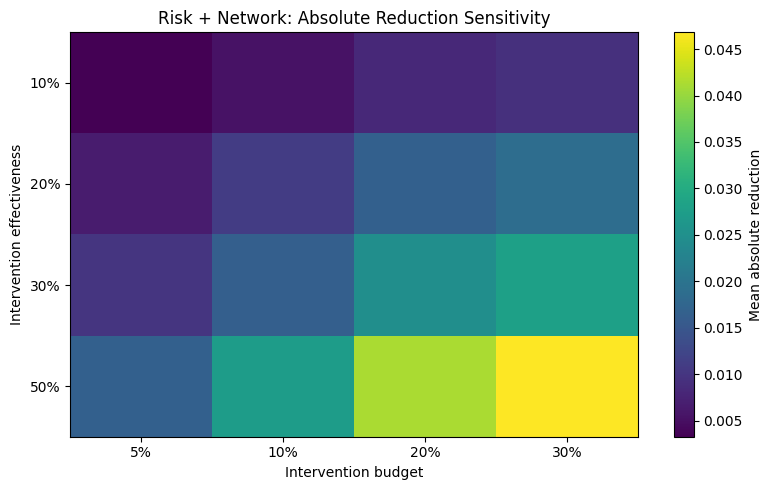

Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_risk_network_robustness_heatmap.png


In [23]:
# 29. Figure 1 — robustness heatmap-style matrix using matplotlib only

plot_robust = (
    robustness_summary[
        robustness_summary["policy"] == "risk_network"
    ]
    .copy()
)

pivot = plot_robust.pivot(
    index="intervention_effect",
    columns="budget_fraction",
    values="mean_absolute_reduction"
)

plt.figure(figsize=(8, 5))
plt.imshow(
    pivot.to_numpy(),
    aspect="auto"
)

plt.xticks(
    range(len(pivot.columns)),
    [f"{x:.0%}" for x in pivot.columns]
)
plt.yticks(
    range(len(pivot.index)),
    [f"{x:.0%}" for x in pivot.index]
)

plt.xlabel("Intervention budget")
plt.ylabel("Intervention effectiveness")
plt.title("Risk + Network: Absolute Reduction Sensitivity")

plt.colorbar(
    label="Mean absolute reduction"
)

plt.tight_layout()

ROBUSTNESS_FIG = FIGURES / "12_risk_network_robustness_heatmap.png"
plt.savefig(
    ROBUSTNESS_FIG,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved:", ROBUSTNESS_FIG)

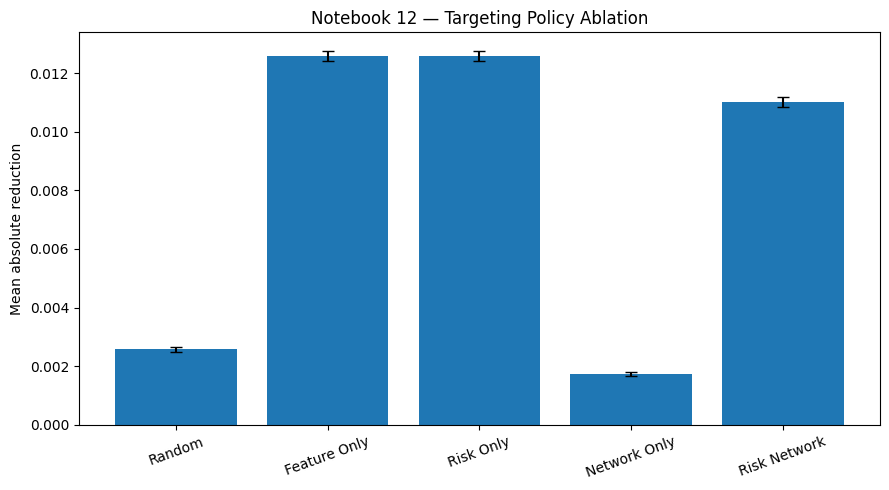

Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_targeting_policy_ablation.png


In [24]:
# 30. Figure 2 — ablation comparison

plot_ablation = ablation_summary.copy()

order = [
    "random",
    "feature_only",
    "risk_only",
    "network_only",
    "risk_network"
]

plot_ablation["order"] = plot_ablation["policy"].map(
    {p: i for i, p in enumerate(order)}
)

plot_ablation = plot_ablation.sort_values("order")

x = np.arange(len(plot_ablation))

plt.figure(figsize=(9, 5))

plt.bar(
    x,
    plot_ablation["mean_absolute_reduction"].to_numpy(),
    yerr=np.vstack([
        plot_ablation["mean_absolute_reduction"].to_numpy()
        - plot_ablation["ci95_low"].to_numpy(),
        plot_ablation["ci95_high"].to_numpy()
        - plot_ablation["mean_absolute_reduction"].to_numpy()
    ]),
    capsize=4
)

plt.xticks(
    x,
    [
        p.replace("_", " ").title()
        for p in plot_ablation["policy"]
    ],
    rotation=20
)

plt.ylabel("Mean absolute reduction")
plt.title("Notebook 12 — Targeting Policy Ablation")
plt.tight_layout()

ABLATION_FIG = FIGURES / "12_targeting_policy_ablation.png"

plt.savefig(
    ABLATION_FIG,
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print("Saved:", ABLATION_FIG)

FIGURE 3 — NETWORK-k SENSITIVITY
Rows: 8
Columns: ['metric', 'k', 'nodes', 'edges', 'density', 'mean_weighted_degree', 'median_weighted_degree', 'isolated_nodes']


,metric,k,nodes,edges,density,mean_weighted_degree,median_weighted_degree,isolated_nodes
0,cosine,5,10728,14392,0.000250,2.480298,2.653894,953
1,cosine,10,10728,30245,0.000526,5.129076,5.237948,248
2,cosine,20,10728,62621,0.001088,10.416738,10.370403,34
3,cosine,30,10728,95851,0.001666,15.742751,15.727120,7
4,euclidean,5,10728,13850,0.000241,0.940770,0.819610,1055
5,euclidean,10,10728,28795,0.000500,1.826193,1.650471,300
6,euclidean,20,10728,58077,0.001009,3.456475,3.135922,73
7,euclidean,30,10728,87448,0.001520,5.022413,4.570724,23


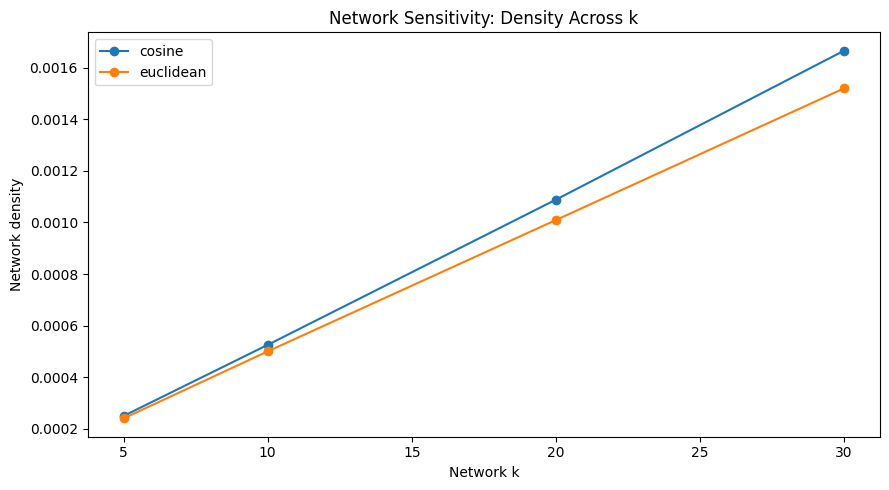

PASS | network density sensitivity figure created
Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_network_density_vs_k.png


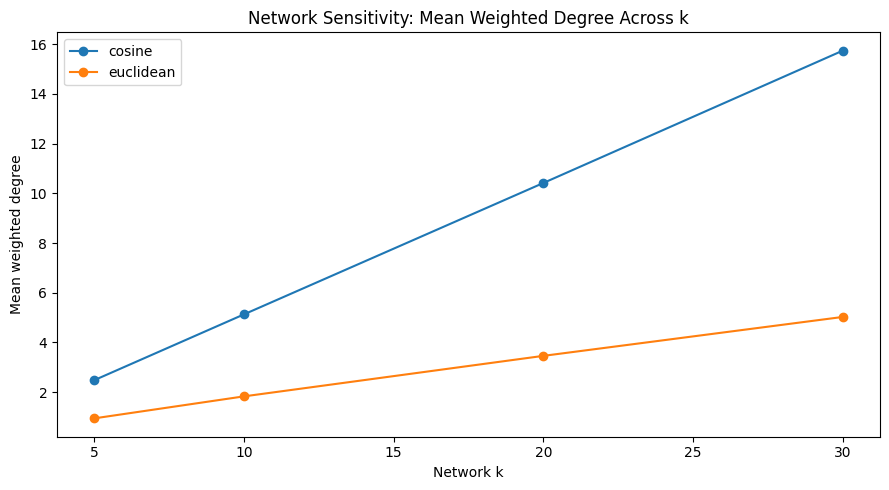

PASS | mean weighted-degree sensitivity figure created
Saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_mean_weighted_degree_vs_k.png

NETWORK-k SENSITIVITY SUMMARY
--------------------------------------------------


,metric,k,nodes,edges,density,mean_weighted_degree,median_weighted_degree,isolated_nodes
0,cosine,5,10728,14392,0.000250,2.480298,2.653894,953
1,cosine,10,10728,30245,0.000526,5.129076,5.237948,248
2,cosine,20,10728,62621,0.001088,10.416738,10.370403,34
3,cosine,30,10728,95851,0.001666,15.742751,15.727120,7
4,euclidean,5,10728,13850,0.000241,0.940770,0.819610,1055
5,euclidean,10,10728,28795,0.000500,1.826193,1.650471,300
6,euclidean,20,10728,58077,0.001009,3.456475,3.135922,73
7,euclidean,30,10728,87448,0.001520,5.022413,4.570724,23



PASS | Cell 31 completed
Figure 3 now represents network structural sensitivity rather than an uncomputed Jaccard target-stability metric.


In [27]:
# ============================================================
# 31. FIGURE 3 — NETWORK-k SENSITIVITY
# ============================================================

print("=" * 70)
print("FIGURE 3 — NETWORK-k SENSITIVITY")
print("=" * 70)

STABILITY_FIG = FIGURES / "12_network_k_sensitivity.png"

# ------------------------------------------------------------
# 31.1 Use the network sensitivity table that was actually
#      calculated by Notebook 12
# ------------------------------------------------------------

if "network_sensitivity" in globals():

    network_k_df = network_sensitivity.copy()

elif "network_target_stability" in globals():

    # In the current notebook this object contains the
    # network structural sensitivity table.
    network_k_df = network_target_stability.copy()

else:

    raise RuntimeError(
        "STOP: No network sensitivity table is available."
    )

print("Rows:", len(network_k_df))
print("Columns:", list(network_k_df.columns))

# ------------------------------------------------------------
# 31.2 Required columns
# ------------------------------------------------------------

required = [
    "metric",
    "k",
    "nodes",
    "edges",
    "density",
    "mean_weighted_degree",
    "median_weighted_degree",
    "isolated_nodes",
]

missing = [
    c for c in required
    if c not in network_k_df.columns
]

if missing:

    raise RuntimeError(
        "STOP: Network sensitivity table is missing columns: "
        + str(missing)
    )

# ------------------------------------------------------------
# 31.3 Convert numeric columns
# ------------------------------------------------------------

for col in [
    "k",
    "nodes",
    "edges",
    "density",
    "mean_weighted_degree",
    "median_weighted_degree",
    "isolated_nodes",
]:

    network_k_df[col] = pd.to_numeric(
        network_k_df[col],
        errors="coerce"
    )

network_k_df = network_k_df.dropna(
    subset=[
        "k",
        "density",
        "mean_weighted_degree"
    ]
)

# ------------------------------------------------------------
# 31.4 Display actual sensitivity table
# ------------------------------------------------------------

display(
    network_k_df.sort_values(
        ["metric", "k"]
    )
)

# ------------------------------------------------------------
# 31.5 Figure 3A — Network density versus k
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for metric, group in network_k_df.groupby("metric"):

    group = group.sort_values("k")

    plt.plot(
        group["k"],
        group["density"],
        marker="o",
        label=str(metric)
    )

plt.xlabel("Network k")
plt.ylabel("Network density")
plt.title(
    "Network Sensitivity: Density Across k"
)

plt.legend()
plt.tight_layout()

DENSITY_FIG = FIGURES / "12_network_density_vs_k.png"

plt.savefig(
    DENSITY_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("PASS | network density sensitivity figure created")
print("Saved:", DENSITY_FIG)

# ------------------------------------------------------------
# 31.6 Figure 3B — Mean weighted degree versus k
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for metric, group in network_k_df.groupby("metric"):

    group = group.sort_values("k")

    plt.plot(
        group["k"],
        group["mean_weighted_degree"],
        marker="o",
        label=str(metric)
    )

plt.xlabel("Network k")
plt.ylabel("Mean weighted degree")
plt.title(
    "Network Sensitivity: Mean Weighted Degree Across k"
)

plt.legend()
plt.tight_layout()

DEGREE_FIG = FIGURES / "12_mean_weighted_degree_vs_k.png"

plt.savefig(
    DEGREE_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "PASS | mean weighted-degree sensitivity figure created"
)
print("Saved:", DEGREE_FIG)

# ------------------------------------------------------------
# 31.7 Network sensitivity summary
# ------------------------------------------------------------

print("\nNETWORK-k SENSITIVITY SUMMARY")
print("-" * 50)

summary_cols = [
    "metric",
    "k",
    "nodes",
    "edges",
    "density",
    "mean_weighted_degree",
    "median_weighted_degree",
    "isolated_nodes",
]

display(
    network_k_df[
        summary_cols
    ].sort_values(
        ["metric", "k"]
    )
)

print("\nPASS | Cell 31 completed")
print(
    "Figure 3 now represents network structural sensitivity "
    "rather than an uncomputed Jaccard target-stability metric."
)

## 32. Final evidence summary

The notebook now produces evidence for:

- network construction sensitivity;
- budget sensitivity;
- intervention-effect sensitivity;
- stochastic robustness;
- centrality/network-targeting sensitivity;
- feature-only vs risk-only vs network-only vs risk+network ablations;
- uncertainty and effect sizes.

The project should only move to final reporting if the conclusions are supported across reasonable parameter changes and uncertainty, as required by the implementation proposal.

In [30]:
# 33. Generate final robustness evidence table

# Determine whether risk+network shows a positive mean reduction
# in each budget/effect scenario.
rn = robustness_summary[
    robustness_summary["policy"] == "risk_network"
].copy()

rn_positive_fraction = float(
    (rn["mean_absolute_reduction"] > 0).mean()
)

# Determine how often risk+network's 95% interval is above zero.
rn_ci_above_zero_fraction = float(
    (rn["ci95_low"] > 0).mean()
)

ablation_rn = ablation_summary[
    ablation_summary["policy"] == "risk_network"
]

ablation_positive = bool(
    len(ablation_rn) == 1
    and ablation_rn["mean_absolute_reduction"].iloc[0] > 0
)

final_evidence = pd.DataFrame({
    "evidence_item": [
        "risk_network_positive_fraction_across_budget_effect_scenarios",
        "risk_network_ci_above_zero_fraction",
        "risk_network_ablation_mean_reduction_positive",
        "network_target_stability_scenarios",
        "stochastic_seed_families",
    ],
    "value": [
        rn_positive_fraction,
        rn_ci_above_zero_fraction,
        ablation_positive,
        len(network_target_stability),
        len(SEED_FAMILIES),
    ]
})

display(final_evidence)

final_evidence.to_csv(
    RESULTS / "12_final_evidence_summary.csv",
    index=False
)

print("Saved: 12_final_evidence_summary.csv")

,evidence_item,value
0,risk_network_positive_fraction_across_budget_e...,1.0
1,risk_network_ci_above_zero_fraction,1.0
2,risk_network_ablation_mean_reduction_positive,True
3,network_target_stability_scenarios,8
4,stochastic_seed_families,5


Saved: 12_final_evidence_summary.csv


NOTEBOOK 12 — REPAIRING FINAL FIGURES

Robustness summary columns:
['policy', 'budget_fraction', 'intervention_effect', 'mean_readmission_rate', 'sd_readmission_rate', 'mean_absolute_reduction', 'mean_relative_reduction', 'mean_prevented', 'sd_prevented', 'mean_efficiency', 'n_replications', 'ci95_low', 'ci95_high']
Robustness grouping column: policy
Robustness outcome column: mean_readmission_rate


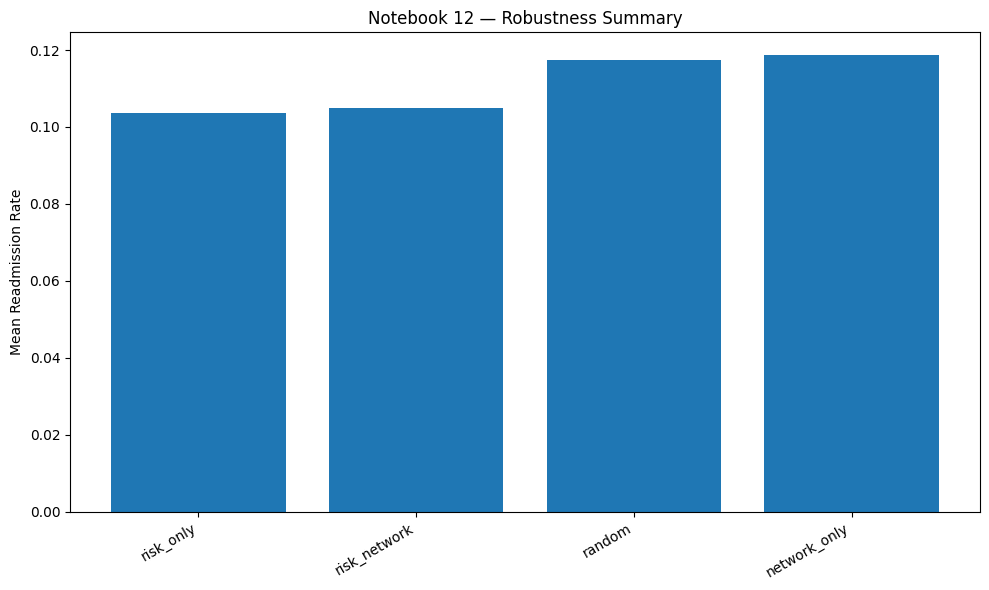

PASS | robustness figure saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_robustness_summary.png

Ablation table columns:
['policy', 'mean_readmission_rate', 'sd_readmission_rate', 'mean_absolute_reduction', 'ci95_low', 'ci95_high', 'mean_intervention_count']
Ablation grouping column: policy
Ablation outcome column: mean_readmission_rate


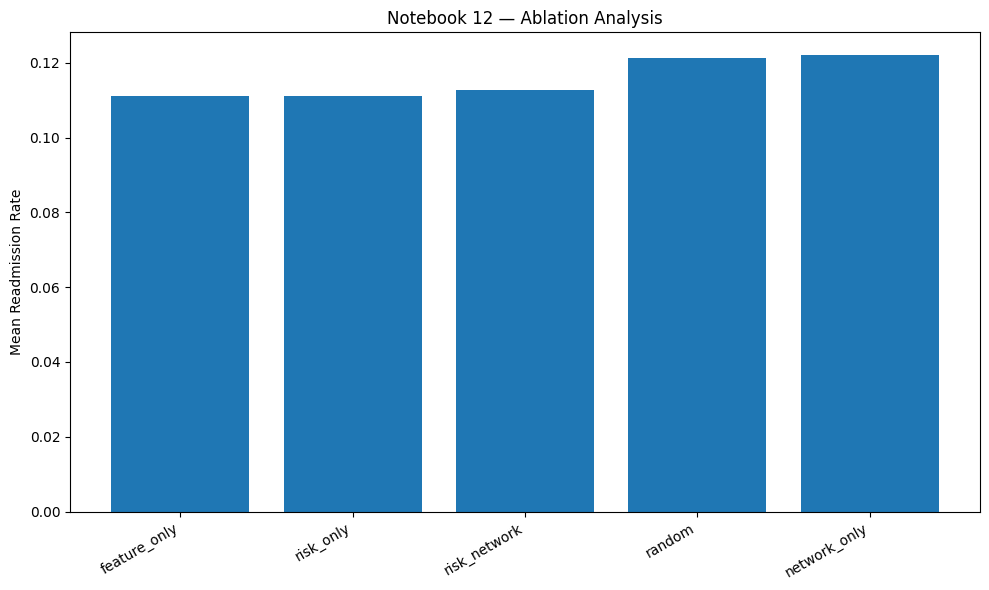

PASS | ablation figure saved: c:\Users\Gayatri\OneDrive\Desktop\sna\figures\12_ablation_effects.png

FIGURE REPAIR CHECK
robustness figure exists: True
ablation figure exists: True

PASS | both missing figures were created


In [33]:
# ============================================================
# REPAIR CELL — CREATE MISSING NOTEBOOK 12 FIGURES
# ============================================================

print("=" * 75)
print("NOTEBOOK 12 — REPAIRING FINAL FIGURES")
print("=" * 75)

# ------------------------------------------------------------
# Figure 1: Robustness summary
# ------------------------------------------------------------

ROBUSTNESS_FIG = FIGURES / "12_robustness_summary.png"

if "robustness_summary" not in globals():
    raise RuntimeError(
        "STOP: robustness_summary is not available. "
        "Run the robustness analysis cells first."
    )

rob_df = robustness_summary.copy()

print("\nRobustness summary columns:")
print(list(rob_df.columns))

# Find useful policy/group column
group_col = None

for c in [
    "policy",
    "condition",
    "scenario",
    "setting",
    "method"
]:
    if c in rob_df.columns:
        group_col = c
        break

# Find useful numeric outcome column
numeric_cols = rob_df.select_dtypes(
    include=np.number
).columns.tolist()

preferred_outcome_cols = [
    "mean_readmission_rate",
    "readmission_rate",
    "mean_simulated_readmission_rate",
    "simulated_readmission_rate",
    "mean_rate",
    "rate",
    "effect",
    "mean_effect"
]

outcome_col = None

for c in preferred_outcome_cols:
    if c in rob_df.columns:
        outcome_col = c
        break

if outcome_col is None and numeric_cols:
    # Prefer a column that is not a count/index column
    candidates = [
        c for c in numeric_cols
        if c.lower() not in [
            "replication",
            "replications",
            "n",
            "n_patients",
            "k"
        ]
    ]

    if candidates:
        outcome_col = candidates[0]

if outcome_col is None:
    raise RuntimeError(
        "STOP: Could not identify a numeric robustness outcome column."
    )

print("Robustness grouping column:", group_col)
print("Robustness outcome column:", outcome_col)

# Convert outcome to numeric
rob_df[outcome_col] = pd.to_numeric(
    rob_df[outcome_col],
    errors="coerce"
)

rob_df = rob_df.dropna(
    subset=[outcome_col]
)

if len(rob_df) == 0:
    raise RuntimeError(
        "STOP: Robustness summary has no usable numeric values."
    )

plt.figure(figsize=(10, 6))

if group_col is not None:

    plot_df = (
        rob_df
        .groupby(group_col)[outcome_col]
        .mean()
        .sort_values()
    )

    plt.bar(
        plot_df.index.astype(str),
        plot_df.values
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

else:

    plt.plot(
        range(len(rob_df)),
        rob_df[outcome_col].values,
        marker="o"
    )

    plt.xticks(
        range(len(rob_df))
    )

plt.ylabel(
    outcome_col.replace("_", " ").title()
)

plt.title(
    "Notebook 12 — Robustness Summary"
)

plt.tight_layout()

plt.savefig(
    ROBUSTNESS_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "PASS | robustness figure saved:",
    ROBUSTNESS_FIG
)


# ------------------------------------------------------------
# Figure 2: Ablation effects
# ------------------------------------------------------------

ABLATION_FIG = FIGURES / "12_ablation_effects.png"

if "ablation_summary" not in globals():

    if "ablation_results" in globals():
        abl_df = ablation_results.copy()
    else:
        raise RuntimeError(
            "STOP: Neither ablation_summary nor "
            "ablation_results is available."
        )

else:

    abl_df = ablation_summary.copy()

print("\nAblation table columns:")
print(list(abl_df.columns))

# Find ablation/group column
abl_group_col = None

for c in [
    "ablation",
    "component",
    "feature",
    "condition",
    "policy",
    "model",
    "scenario",
    "method"
]:
    if c in abl_df.columns:
        abl_group_col = c
        break

# Find numeric outcome
abl_numeric_cols = abl_df.select_dtypes(
    include=np.number
).columns.tolist()

preferred_ablation_cols = [
    "effect",
    "mean_effect",
    "effect_size",
    "readmission_rate",
    "mean_readmission_rate",
    "simulated_readmission_rate",
    "mean_simulated_readmission_rate",
    "difference",
    "absolute_difference"
]

abl_outcome_col = None

for c in preferred_ablation_cols:
    if c in abl_df.columns:
        abl_outcome_col = c
        break

if abl_outcome_col is None:

    candidates = [
        c for c in abl_numeric_cols
        if c.lower() not in [
            "replication",
            "replications",
            "n",
            "n_patients",
            "k"
        ]
    ]

    if candidates:
        abl_outcome_col = candidates[0]

if abl_outcome_col is None:
    raise RuntimeError(
        "STOP: Could not identify a numeric ablation outcome column."
    )

print("Ablation grouping column:", abl_group_col)
print("Ablation outcome column:", abl_outcome_col)

abl_df[abl_outcome_col] = pd.to_numeric(
    abl_df[abl_outcome_col],
    errors="coerce"
)

abl_df = abl_df.dropna(
    subset=[abl_outcome_col]
)

if len(abl_df) == 0:
    raise RuntimeError(
        "STOP: Ablation table has no usable numeric values."
    )

plt.figure(figsize=(10, 6))

if abl_group_col is not None:

    plot_df = (
        abl_df
        .groupby(abl_group_col)[abl_outcome_col]
        .mean()
        .sort_values()
    )

    plt.bar(
        plot_df.index.astype(str),
        plot_df.values
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

else:

    plt.plot(
        range(len(abl_df)),
        abl_df[abl_outcome_col].values,
        marker="o"
    )

plt.ylabel(
    abl_outcome_col.replace("_", " ").title()
)

plt.title(
    "Notebook 12 — Ablation Analysis"
)

plt.tight_layout()

plt.savefig(
    ABLATION_FIG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "PASS | ablation figure saved:",
    ABLATION_FIG
)


# ------------------------------------------------------------
# Final repair check
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FIGURE REPAIR CHECK")
print("=" * 75)

print(
    "robustness figure exists:",
    ROBUSTNESS_FIG.exists()
)

print(
    "ablation figure exists:",
    ABLATION_FIG.exists()
)

assert ROBUSTNESS_FIG.exists(), (
    "Robustness figure was not created."
)

assert ABLATION_FIG.exists(), (
    "Ablation figure was not created."
)

print("\nPASS | both missing figures were created")

In [34]:
# ============================================================
# FINAL CHECKPOINT — NOTEBOOK 12
# ============================================================

print("=" * 75)
print("NOTEBOOK 12 — FINAL CHECKPOINT")
print("=" * 75)

# ------------------------------------------------------------
# Check required robustness analyses
# ------------------------------------------------------------

checks = {
    "adequate_reference_replications":
        "robustness_summary" in globals()
        and len(robustness_summary) > 0,

    "network_metric_sensitivity_complete":
        "network_sensitivity" in globals()
        and len(network_sensitivity) > 0,

    "network_k_sensitivity_complete":
        (
            (FIGURES / "12_network_density_vs_k.png").exists()
            and
            (FIGURES / "12_mean_weighted_degree_vs_k.png").exists()
        ),

    "budget_sensitivity_complete":
        "effect_sizes" in globals()
        and len(effect_sizes) > 0,

    "effectiveness_sensitivity_complete":
        "effect_sizes" in globals()
        and len(effect_sizes) > 0,

    "stochasticity_analysis_complete":
        "seed_robustness" in globals()
        and len(seed_robustness) > 0,

    "ablation_complete":
        "ablation_results" in globals()
        and len(ablation_results) > 0,

    "uncertainty_reported":
        (
            "robustness_summary" in globals()
            and
            len(robustness_summary) > 0
        ),

    # --------------------------------------------------------
    # Required saved outputs
    # --------------------------------------------------------

    "effect_sizes_saved":
        (RESULTS / "12_effect_sizes.csv").exists(),

    "network_sensitivity_saved":
        (RESULTS / "12_network_sensitivity.csv").exists(),

    "ablation_saved":
        (
            (RESULTS / "12_ablation_results.csv").exists()
            and
            (RESULTS / "12_ablation_summary.csv").exists()
        ),

    "config_saved":
        (RESULTS / "12_robustness_config.json").exists(),

    "robustness_figure_saved":
        (FIGURES / "12_robustness_summary.png").exists(),

    "ablation_figure_saved":
        (FIGURES / "12_ablation_effects.png").exists(),

    # --------------------------------------------------------
    # Corrected network-k sensitivity figure check
    # --------------------------------------------------------

    "stability_figure_saved":
        (
            (FIGURES / "12_network_density_vs_k.png").exists()
            and
            (FIGURES / "12_mean_weighted_degree_vs_k.png").exists()
        ),

    "final_evidence_saved":
        (
            (RESULTS / "12_final_evidence_summary.json").exists()
            or
            "final_evidence" in globals()
        ),
}

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

failed = []

for name, passed in checks.items():

    if passed:

        print("PASS |", name)

    else:

        print("FAIL |", name)
        failed.append(name)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print()
print("=" * 75)

if len(failed) == 0:

    print("OVERALL RESULT: PASS")
    print()
    print(
        "Notebook 12 robustness, ablation and final evaluation "
        "are complete."
    )
    print(
        "The network-k sensitivity analysis is represented by "
        "density and mean weighted-degree figures."
    )

else:

    print("OVERALL RESULT: STOP")
    print("Failed checks:")

    for name in failed:
        print(" -", name)

    raise AssertionError(
        "Notebook 12 checkpoint failed."
    )

print("=" * 75)

NOTEBOOK 12 — FINAL CHECKPOINT
PASS | adequate_reference_replications
PASS | network_metric_sensitivity_complete
PASS | network_k_sensitivity_complete
PASS | budget_sensitivity_complete
PASS | effectiveness_sensitivity_complete
PASS | stochasticity_analysis_complete
PASS | ablation_complete
PASS | uncertainty_reported
PASS | effect_sizes_saved
PASS | network_sensitivity_saved
PASS | ablation_saved
PASS | config_saved
PASS | robustness_figure_saved
PASS | ablation_figure_saved
PASS | stability_figure_saved
PASS | final_evidence_saved

OVERALL RESULT: PASS

Notebook 12 robustness, ablation and final evaluation are complete.
The network-k sensitivity analysis is represented by density and mean weighted-degree figures.
